In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
df = pd.read_csv("../data/model_data.csv", index_col=0, parse_dates=True)

df.head()

,vol,vol_lag1,vol_lag5,vol_lag10,vol_lag21,target
Date,,,,,,
2015-03-05,0.076598,0.088956,0.117697,0.138447,0.178844,0.092106
2015-03-06,0.092106,0.076598,0.106633,0.138762,0.167059,0.086750
2015-03-09,0.086750,0.092106,0.104769,0.130694,0.165991,0.104234
2015-03-10,0.104234,0.086750,0.092913,0.128510,0.161691,0.103367
2015-03-11,0.103367,0.104234,0.088956,0.128742,0.150425,0.106207


In [3]:
X = df[["vol_lag1", "vol_lag5", "vol_lag10", "vol_lag21"]]
y = df["target"]

In [4]:
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

In [5]:
y_pred_baseline = X_test["vol_lag1"]

rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
mae = mean_absolute_error(y_test, y_pred_baseline)

print("Baseline RMSE:", rmse)
print("Baseline MAE:", mae)

Baseline RMSE: 0.010238119681013222
Baseline MAE: 0.0069230509011389526


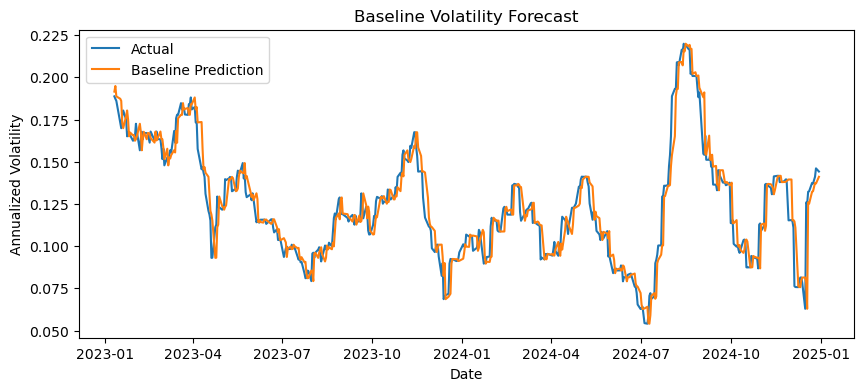

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred_baseline, label="Baseline Prediction")
plt.title("Baseline Volatility Forecast")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.show()

In [7]:
from sklearn.ensemble import RandomForestRegressor

In [8]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=5, n_estimators=300, random_state=42)

In [9]:
y_pred_rf = rf.predict(X_test)

In [10]:
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest MAE:", rf_mae)
print("Baseline RMSE:", rmse)
print("Baseline MAE:", mae)

Random Forest RMSE: 0.01023230030201223
Random Forest MAE: 0.007195207380148981
Baseline RMSE: 0.010238119681013222
Baseline MAE: 0.0069230509011389526


In [26]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import ExtraTreesRegressor, StackingRegressor, RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

In [27]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)

In [28]:
extra_trees = ExtraTreesRegressor(
    n_estimators=500,
    max_depth=6,
    min_samples_leaf=5,
    random_state=42
)

extra_trees.fit(X_train, y_train)

y_pred_extra = extra_trees.predict(X_test)

extra_rmse = np.sqrt(mean_squared_error(y_test, y_pred_extra))
extra_mae = mean_absolute_error(y_test, y_pred_extra)

In [29]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)

In [30]:
base_models = [
    ("ridge", Ridge(alpha=1.0)),
    ("rf", RandomForestRegressor(
        n_estimators=300,
        max_depth=5,
        random_state=42
    )),
    ("extra", ExtraTreesRegressor(
        n_estimators=500,
        max_depth=6,
        min_samples_leaf=5,
        random_state=42
    )),
    ("xgb", XGBRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    ))
]

stacking = StackingRegressor(
    estimators=base_models,
    final_estimator=Ridge(alpha=1.0),
    passthrough=True,
    cv=5
)

stacking.fit(X_train, y_train)

y_pred_stack = stacking.predict(X_test)

stack_rmse = np.sqrt(mean_squared_error(y_test, y_pred_stack))
stack_mae = mean_absolute_error(y_test, y_pred_stack)

In [15]:
from arch import arch_model

In [16]:
returns = pd.read_csv("../data/returns.csv", index_col=0, parse_dates=True)

spy_returns = returns["SPY"] * 100  # scale returns for GARCH stability

In [17]:
spy_train = spy_returns.loc[X_train.index]
spy_test = spy_returns.loc[X_test.index]

In [18]:
garch = arch_model(
    spy_train,
    vol="Garch",
    p=1,
    q=1,
    mean="Constant",
    dist="normal"
)

garch_result = garch.fit(disp="off")
print(garch_result.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                    SPY   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2573.46
Distribution:                  Normal   AIC:                           5154.91
Method:            Maximum Likelihood   BIC:                           5177.27
                                        No. Observations:                 1978
Date:                Tue, May 05 2026   Df Residuals:                     1977
Time:                        01:48:49   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0860  1.660e-02      5.182  2.198e-07 [5.349e-0

In [22]:
forecast = garch_result.forecast(horizon=len(spy_test), reindex=False)

garch_var = forecast.variance.values[-1, :]
garch_vol = np.sqrt(garch_var) / 100 * np.sqrt(252)

In [23]:
garch_pred = pd.Series(garch_vol, index=y_test.index)

garch_rmse = np.sqrt(mean_squared_error(y_test, garch_pred))
garch_mae = mean_absolute_error(y_test, garch_pred)

print("GARCH RMSE:", garch_rmse)
print("GARCH MAE:", garch_mae)

GARCH RMSE: 0.10778220588781764
GARCH MAE: 0.10083261220493335


In [31]:
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Random Forest",
        "GARCH(1,1)",
        "Ridge",
        "Extra Trees",
        "XGBoost",
        "Stacking"
    ],
    "RMSE": [
        rmse,
        rf_rmse,
        garch_rmse,
        ridge_rmse,
        extra_rmse,
        xgb_rmse,
        stack_rmse
    ],
    "MAE": [
        mae,
        rf_mae,
        garch_mae,
        ridge_mae,
        extra_mae,
        xgb_mae,
        stack_mae
    ]
})

results.sort_values("RMSE")

,Model,RMSE,MAE
5,XGBoost,0.009912,0.007210
1,Random Forest,0.010232,0.007195
0,Baseline,0.010238,0.006923
6,Stacking,0.010466,0.007258
4,Extra Trees,0.010538,0.007469
3,Ridge,0.010577,0.007483
2,"GARCH(1,1)",0.107782,0.100833


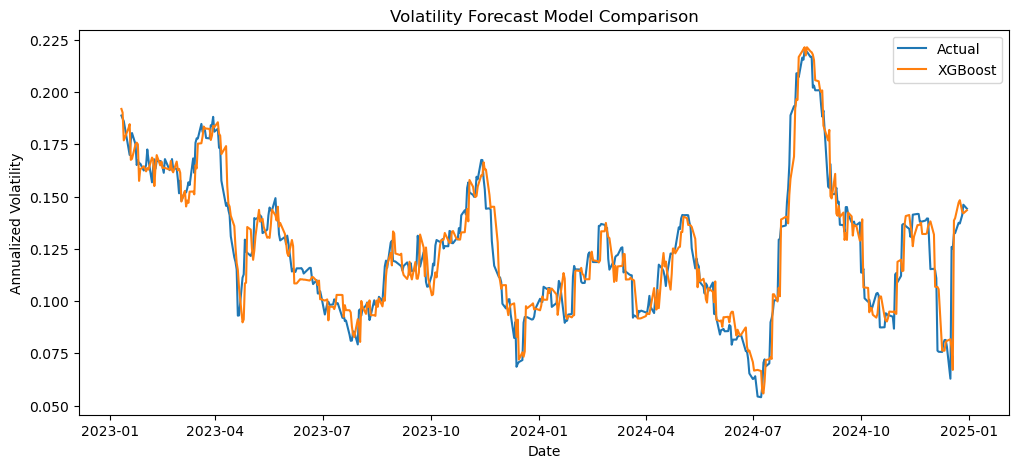

In [33]:
plt.figure(figsize=(12, 5))

plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred_xgb, label="XGBoost")

plt.title("Volatility Forecast Model Comparison")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.show()